# KMeans 第三课：算法迭代与手写实现

第二课已经手算了一轮“分配—更新”。这一课把它写成一个可以反复迭代的 NumPy 算法。

学习目标：

```text
初始化质心
-> 计算距离矩阵
-> 分配簇编号
-> 更新质心
-> 计算 SSE
-> 判断收敛
```

手写的目的不是替代 sklearn，而是看清 `fit` 内部最核心的计算链。

In [1]:
import os

# sklearn 1.7.x 在 Windows + MKL 的小数据集上建议限制 OpenMP 线程数
os.environ["OMP_NUM_THREADS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

np.set_printoptions(precision=3, suppress=True)

from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score

## 1. 准备二维数据

`make_blobs` 生成三团数据。它也返回人工标签，但手写 K-means 训练时只使用 `X`。

In [2]:
X, true_labels = make_blobs(
    n_samples=180,
    centers=[(-5, -2), (0, 5), (5, -1)],
    cluster_std=[0.8, 1.0, 0.9],
    random_state=22,
)

print("X.shape:", X.shape)
print("训练只使用 X，不使用 true_labels")

X.shape: (180, 2)
训练只使用 X，不使用 true_labels


## 2. 初始化质心

最简单的方法是从样本中随机选择 $K$ 个不同的点：

$$
\mu_1,\mu_2,\ldots,\mu_K
$$

固定 `random_state` 只是为了让学习过程可复现。随机初始化可能不稳定，后面会学习 `k-means++`。

In [3]:
def initialize_centers(X, k, random_state=22):
    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=k, replace=False)
    return X[indices].copy()


initial_centers = initialize_centers(X, k=3)
print("初始质心:")
print(initial_centers)

初始质心:
[[ 4.541 -1.631]
 [ 3.74  -1.155]
 [-4.71  -1.555]]


## 3. 分配样本

距离矩阵形状为 `(样本数, K)`。对每一行使用 `argmin`，得到最近质心的编号：

$$
c_i=\arg\min_k\lVert x_i-\mu_k\rVert_2^2
$$

In [4]:
def assign_clusters(X, centers):
    differences = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    squared_distances = np.sum(differences ** 2, axis=2)
    labels = np.argmin(squared_distances, axis=1)
    return labels, squared_distances


first_labels, first_distances = assign_clusters(X, initial_centers)
print("距离矩阵形状:", first_distances.shape)
print("前 10 个簇编号:", first_labels[:10])

距离矩阵形状: (180, 3)
前 10 个簇编号: [1 2 1 0 2 2 2 1 2 1]


## 4. 更新质心并处理空簇

正常情况下，第 $k$ 个新质心是该簇样本的均值：

$$
\mu_k=\frac{1}{|C_k|}\sum_{x_i\in C_k}x_i
$$

随机初始化较差时，某个质心可能一个样本也分不到，这叫空簇。直接对空数组求均值会产生 `RuntimeWarning` 和 `NaN`。

本手写版本采用明确策略：空簇暂时保留旧质心。因此代码先检查样本数量，不对空数组求均值，这也是本章警告修复的一部分。

In [5]:
def update_centers(X, labels, old_centers):
    new_centers = old_centers.copy()
    for cluster_id in range(len(old_centers)):
        members = X[labels == cluster_id]
        if len(members) > 0:
            new_centers[cluster_id] = members.mean(axis=0)
    return new_centers


first_updated_centers = update_centers(X, first_labels, initial_centers)
print("第一次更新后的质心:")
print(first_updated_centers)

第一次更新后的质心:
[[ 5.366 -1.1  ]
 [ 1.558  3.542]
 [-4.403 -0.892]]


## 5. 计算 SSE 与收敛条件

$$
SSE=\sum_i\lVert x_i-\mu_{c_i}\rVert_2^2
$$

每一轮记录 SSE，可以检查目标函数是否在下降。

质心最大移动量小于容差 `tol` 时停止：

$$
\max_k\lVert\mu_k^{new}-\mu_k^{old}\rVert_2 < tol
$$

In [6]:
def calculate_sse(X, labels, centers):
    residuals = X - centers[labels]
    return float(np.sum(residuals ** 2))


def manual_kmeans(X, k, random_state=22, max_iter=100, tol=1e-4):
    centers = initialize_centers(X, k, random_state)
    history = []

    for iteration in range(1, max_iter + 1):
        labels, _ = assign_clusters(X, centers)
        new_centers = update_centers(X, labels, centers)
        center_shift = np.max(np.linalg.norm(new_centers - centers, axis=1))

        # 用新质心重新分配，再计算同一状态下的 SSE
        new_labels, _ = assign_clusters(X, new_centers)
        sse = calculate_sse(X, new_labels, new_centers)
        history.append((iteration, sse, center_shift))

        centers = new_centers
        if center_shift < tol:
            break

    final_labels, _ = assign_clusters(X, centers)
    final_sse = calculate_sse(X, final_labels, centers)
    return final_labels, centers, final_sse, history

## 6. 运行手写 K-means

观察每轮 SSE 和质心移动量。SSE 应当下降或保持不变，移动量最终接近 0。

In [7]:
manual_labels, manual_centers, manual_sse, history = manual_kmeans(X, k=3)

for iteration, sse, shift in history:
    print(f"iteration={iteration:2d}, SSE={sse:9.3f}, max_shift={shift:.6f}")

print("最终质心:")
print(manual_centers)
print("最终 SSE:", round(manual_sse, 3))

iteration= 1, SSE=  725.168, max_shift=5.179879
iteration= 2, SSE=  336.916, max_shift=2.131355
iteration= 3, SSE=  336.916, max_shift=0.000000
最终质心:
[[ 4.887 -0.897]
 [ 0.25   5.225]
 [-4.978 -2.044]]
最终 SSE: 336.916


## 7. 与 sklearn 结果对照

簇编号可能互换，因此不能直接要求两个 `labels` 数组中的数字完全相同。

调整兰德指数 `ARI` 比较的是样本两两是否被分在同一簇，不受簇编号置换影响：

```text
ARI = 1 -> 两种分组完全一致
ARI ≈ 0 -> 接近随机一致程度
```

In [8]:
sklearn_model = KMeans(n_clusters=3, random_state=22, n_init=10)
sklearn_labels = sklearn_model.fit_predict(X)

print("手写 SSE:", round(manual_sse, 3))
print("sklearn inertia_:", round(sklearn_model.inertia_, 3))
print("两种分组的 ARI:", adjusted_rand_score(manual_labels, sklearn_labels))

手写 SSE: 336.916
sklearn inertia_: 336.916
两种分组的 ARI: 1.0


## 8. 可视化结果和 SSE 下降过程

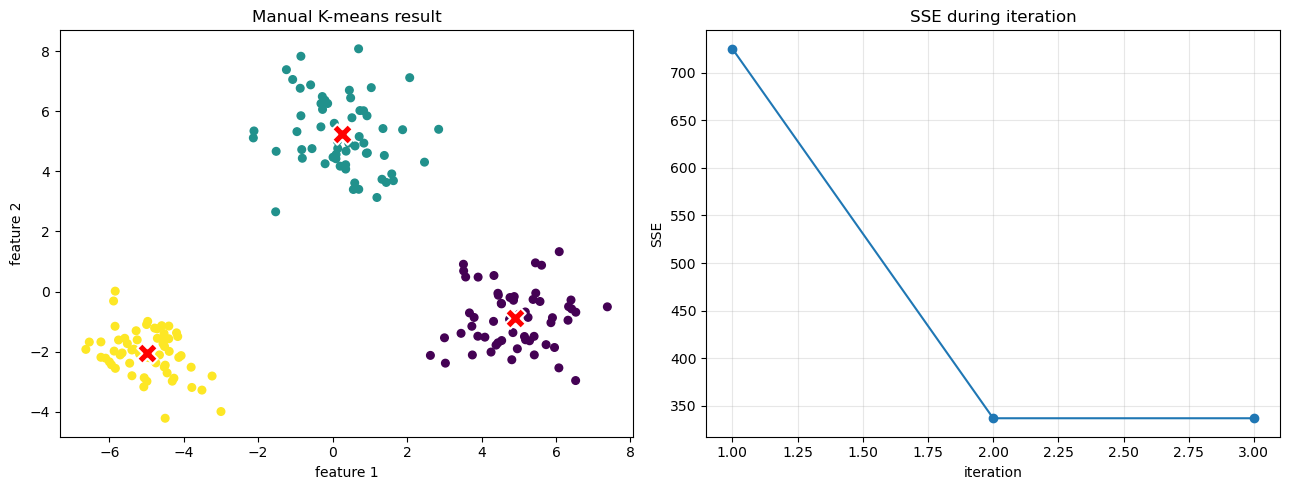

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=manual_labels, cmap="viridis", s=30)
axes[0].scatter(
    manual_centers[:, 0], manual_centers[:, 1],
    c="red", marker="X", s=220, edgecolors="white", linewidths=1.5,
)
axes[0].set_title("Manual K-means result")
axes[0].set_xlabel("feature 1")
axes[0].set_ylabel("feature 2")

iterations = [item[0] for item in history]
sse_values = [item[1] for item in history]
axes[1].plot(iterations, sse_values, marker="o")
axes[1].set_title("SSE during iteration")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("SSE")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. 本课小结

手写 K-means 的核心只有四个函数：

```text
initialize_centers
assign_clusters
update_centers
calculate_sse
```

训练循环负责反复调用它们，并使用质心移动量判断是否收敛。

需要特别记住：

- 距离矩阵的形状是 `(n_samples, K)`；
- `argmin(axis=1)` 给每个样本选择质心；
- 更新质心前要检查空簇，避免均值警告和 `NaN`；
- 簇编号可以互换，比较聚类应使用不依赖编号的指标；
- sklearn 的实现更快、更稳，实际项目优先使用 sklearn。

下一课进入 sklearn 完整工作流。